# Importations

In [1]:
# Numerical and scientific python programming
import numpy as np

import matplotlib.pyplot as plt

# Local importations
from moments.ent_meas import compute_concurrence, compute_binary_entropy, compute_eof

# Binary entropy

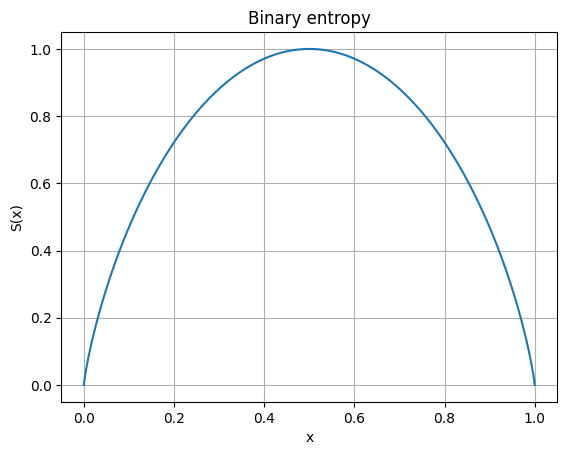

In [2]:
x = np.linspace(0, 1, 1000)

S = compute_binary_entropy(x)

fig, ax = plt.subplots()
ax.plot(x, S)
ax.set(xlabel="x", ylabel="S(x)", title="Binary entropy")
ax.grid(True)
plt.show()

# Concurrence and entanglement of formation

In [3]:
from typing import Union

def compute_pure_LU_ent_classes(theta: Union[np.ndarray, float]) -> np.ndarray:
    rho = np.zeros((4, 4), dtype=complex)
    rho[0, 0] = np.cos(theta)**2
    rho[3, 3] = np.sin(theta)**2
    rho[0, 3] = rho[3, 0] = np.cos(theta)*np.sin(theta)
    return rho

def compute_ent_entropy_LU_ent_classes(theta: Union[np.ndarray, float], tol: float = 1e-12) -> Union[np.ndarray, float]:
    theta = np.asarray(theta)
    result = np.zeros_like(theta, dtype=np.float64)

    lambda1_sq = np.cos(theta)**2
    lambda2_sq = np.sin(theta)**2
    
    mask1 = lambda1_sq > tol
    mask2 = lambda2_sq > tol
    lambda1_valid = lambda1_sq[mask1]
    lambda2_valid = lambda2_sq[mask2]
    
    result[mask1] += -lambda1_valid * np.log2(lambda1_valid)
    result[mask2] += -lambda2_valid * np.log2(lambda2_valid)

    return result.item() if result.ndim == 0 else result

In [4]:
theta_values = np.linspace(0, np.pi/4, 1000)
S = compute_ent_entropy_LU_ent_classes(theta_values)
concurrences = []
EoF = []
for theta in theta_values:
    rho = compute_pure_LU_ent_classes(theta)
    C = compute_concurrence(rho)
    E = compute_eof(rho)
    concurrences.append(C)
    EoF.append(E)

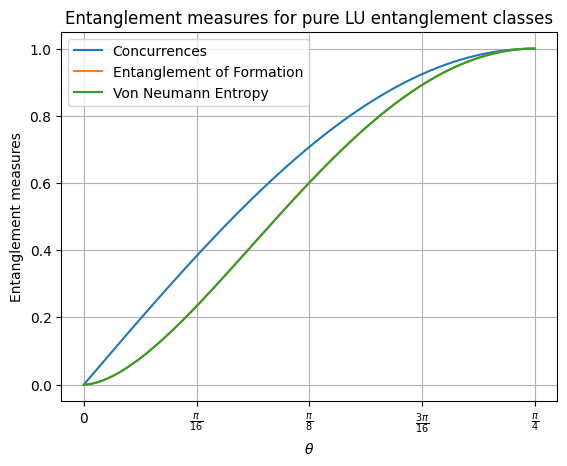

In [5]:
fig, ax = plt.subplots()
ax.plot(theta_values, concurrences, label="Concurrences")
ax.plot(theta_values, EoF, label="Entanglement of Formation")
ax.plot(theta_values, S, label="Von Neumann Entropy")
ax.set(xlabel=r"$\theta$", ylabel="Entanglement measures", title="Entanglement measures for pure LU entanglement classes",
       xticks=np.arange(0, np.pi/4 + 0.01, np.pi/16), xticklabels=[r"$0$", r"$\frac{\pi}{16}$", r"$\frac{\pi}{8}$", r"$\frac{3\pi}{16}$", r"$\frac{\pi}{4}$"])
ax.legend()
ax.grid(True)
plt.show()